## 🔬 Experiment 1: Reasoning Transfer via Precomputed Context

### 🎯 Core Hypothesis
> *Reasoning steps (tokens) computed for a single, complex sample can be extracted, "frozen," and injected as precomputed context into subsequent queries. This transfer will improve the LLM's performance (accuracy/consistency) on new samples of the same domain compared to standard zero-shot generation.*

### ⚙️ Pipeline Architecture
0. **Reasoning Token Extraction:** Prompt Qwen 3.5:4b with a random sample question from the data set "", strip the final answer, and store *only* the reasoning tokens as a static string.
1. **Baseline:** For each sample of the data-set, prompt Qwen 3.5:4b with the sample, turn-off thinking and force the model to only awnser the question.
2. **Injection:** For each sample of the data-set, prompt Qwen 3.5:4b with the sample, turn-off thinking, add the extracted reasoning tokens and force the model to only awnser the question.

### 📊 Evaluation Metrics
* **Accuracy:** Does the injected context increase the rate of correctly solved subsequent samples?
* **Efficiency:** Does the provision of precomputed reasoning reduce the total generation time or token count for subsequent queries?

In [9]:
import time
import json
import os
import subprocess
import random
from datetime import datetime
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from datasets import load_dataset

In [10]:
# Dynamic IP retrieval for Windows host
windows_ip = subprocess.check_output("ip route list default | awk '{print $3}'", shell=True).decode('utf-8').strip()

# Set llm model parameters (qwen3.5:4b)
llm_model = ChatOllama(
    model="qwen3.5:4b", 
    base_url=f"http://{windows_ip}:11434", 
    presence_penalty=1.5,
    temperature=1,
    top_p=0.95,
    top_k=20,
)

In [11]:
# Load WinoGrande dataset and select a subset for the experiment
dataset = load_dataset("allenai/winogrande", "winogrande_s")
experiment0_samples = dataset['validation'].select(range(1000))

In [16]:
import json
import random
from datetime import datetime
from langchain_core.messages import SystemMessage, HumanMessage

# 1. Get a random anchor sample for extraction
anchor_index = random.randint(0, len(experiment0_samples)-1)
anchor_sample = experiment0_samples[anchor_index]
anchor_question = f"Question: {anchor_sample['sentence']}, Options: {anchor_sample['option1']} or {anchor_sample['option2']}."

print(f"Anchor Sample selected (Index {anchor_index}): {anchor_question}")

# 2. Define prompt structures and Placebo Text
system_instruction = "You are a meticulous assistant. Fill in the blank (_) in the sentence with the logically correct option."

baseline_prompt_structure = "Question: {sentence} Options: {option1} or {option2}. Please provide only the correct option as the answer."

# We use the same structure for both Injected Reasoning and the Control Placebo
injected_prompt_structure = "Question: {sentence} Options: {option1} or {option2}. Please provide only the correct option as the answer. \n\n Here is some information to help you: {injection_content}. \n\n Let me repeat the question: {sentence} Choose one of the two options: {option1} or {option2}. Please provide only the correct option as the answer."

control_prompt_structure = "Question: {sentence} Options: {option1} or {option2}. Please provide only the correct option as the answer. \n\n Here is some information to help you: {control_content}. \n\n Let me repeat the question: {sentence} Choose one of the two options: {option1} or {option2}. Please provide only the correct option as the answer."


# Placebo Text (Wikipedia excerpt, unrelated to WinoGrande commonsense) -> https://en.wikipedia.org/wiki/Happiness_is_a_Warm_Gun_(film)
control_text = "Happiness Is a Warm Gun is a feature film by the Swiss director Thomas Imbach, who stages the life and death story of the lovers Petra Kelly and Gert Bastian. Between documentary-like scenes and fictional acting, as well as archive material, the narrative of a love story is created, rolled up from its end. Happiness Is a Warm Gun premiered at the International Locarno Film Festival in August 2001.[1] The film won the Zurich Film Prize 2001[2] and was nominated for the Swiss Film Prize for best feature film and best leading actress. \n\nPLOT: Happiness Is a Warm Gun is about the murder of the green pacifist Petra Kelly, who is shot in her sleep by her life partner Gert Bastian, ex-Bundeswehr-General, before he kills himself. The film begins where the lives of the real characters end. Petra and Gert find themselves in the transit area of a modern airport and settle down in this artificial in-between world, trying to pick up the thread of the past - their political activity - while in their conversations what happened is fragmentary. \n\n Background: After leaving the Bundestag, Kelly lived with her partner Gert Bastian in seclusion in their house in the Tannenbusch district of Bonn. She was seriously ill and suffered from fear of threats (after having received threatening letters). She was on the police's list of endangered personalities, but refused personal protection. According to the police report, Kelly was killed in her sleep by Bastian with his Deringer-type pistol under circumstances that are not completely clear, and Bastian is said to have put an end to his life afterwards, whereby according to a report in Der Spiegel magazine, the gun was aimed from above at a spot just above the forehead. The bodies were found on October 19, 1992 - several weeks after the crime. The exact date could therefore no longer be determined with certainty; the time of death is assumed to be the night of October 1, 1992."

# 3.1 Preprocessing: Generate LLM reasoning for the anchor question
preprocessed_reasoning_tokens = llm_model.invoke([
    SystemMessage(content=system_instruction),
    HumanMessage(content=f"{anchor_question} Please provide only the correct option as the answer.")
], reasoning=True).additional_kwargs.get("reasoning_content")

# 3.2 Preprocessing: Generate LLM reasoning concept tokens for the anchor question (optimized for reasoning injection)
preprocessed_optimized_reasoning_tokens = llm_model.invoke([
    SystemMessage(content=system_instruction),
    HumanMessage(content=f"Analyze this type of problem: '{anchor_question}'. Create a generalized, step-by-step logical strategy or set of rules that can be used to answer any similar commonsense question. Focus on the methodology of comparing context clues.")
], reasoning=True).content.strip()

print("\nPreprocessed Reasoning Tokens:", preprocessed_reasoning_tokens, "\n")

# 4. Initialize new log structure (now tracking 3 states)
experiment_log = {
    "metadata": {
        "dataset": "WinoGrande",
        "sample_size": len(experiment0_samples),
        "anchor_sample_index": anchor_index,
        "anchor_question": anchor_question,
        "injected_reasoning_tokens": preprocessed_reasoning_tokens,
        "control_placebo_text": control_text,
        "system_prompt": system_instruction,
        "baseline_prompt_structure": baseline_prompt_structure,
        "injected_prompt_structure": injected_prompt_structure,
        "control_prompt_structure": injected_prompt_structure
    },
    "results": {}
}

# 5. The main loop
for index, sample in enumerate(experiment0_samples):
    sample_id = f"sample_{index:03d}"
    correct_solution = sample[f"option{sample['answer']}"]
    
    # Cleanly fill prompts via .format() using the template variables
    baseline_human_prompt = baseline_prompt_structure.format(
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )
    
    # Fill with actual Reasoning
    reasoning_human_prompt = injected_prompt_structure.format(
        injection_content=preprocessed_reasoning_tokens,
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )

    # Fill with optimized Reasoning
    reasoning_optimized_human_prompt = injected_prompt_structure.format(
        injection_content=preprocessed_optimized_reasoning_tokens,
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )

    # Fill with Placebo Wikipedia Text
    control_human_prompt = control_prompt_structure.format(
        control_content=control_text,
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )

    # Run 1: Baseline
    response_baseline = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=baseline_human_prompt)
    ], reasoning=False)
    baseline_answer = response_baseline.content.strip()

    # Run 2: Reasoning Injection
    response_reasoning = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=reasoning_human_prompt)
    ], reasoning=False)
    reasoning_answer = response_reasoning.content.strip()

    # Run 3: Optimized Reasoning Injection
    optimized_response_reasoning = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=reasoning_optimized_human_prompt)
    ], reasoning=False)
    optimized_reasoning_answer = response_reasoning.content.strip()

    # Run 4: Placebo Control Injection
    response_control = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=control_human_prompt)
    ], reasoning=False)
    control_answer = response_control.content.strip()

    print(f"{sample_id} - Sol: {correct_solution} | Base: {baseline_answer} | Reason: {reasoning_answer} | opti. Reason: {optimized_reasoning_answer} | Placebo: {control_answer}")
    
    # Write results to the results dictionary
    experiment_log["results"][sample_id] = {
        "solution": correct_solution,
        "llm_baseline": baseline_answer,
        "llm_preprocessedReasoning": reasoning_answer,
        "llm_preprocessedOptimizedReasoning": reasoning_answer,
        "llm_controlPlacebo": control_answer
    }

# 6. Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_filename = f"qwen_experiment_log_{timestamp}.json"

with open(log_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\n✅ Experiment successfully saved in {log_filename}!")

Anchor Sample selected (Index 347): Question: Jane loved travelling internationally. The current country she was in preferred wine over tea because the _ was less available., Options: wine or tea.

Preprocessed Reasoning Tokens: Thinking Process:

1.  **Analyze the Request:** The user wants me to fill in the blank (_) in the given sentence with the logically correct option from the provided choices ("wine" or "tea"). The output should be only the correct option.

2.  **Analyze the Sentence:** "Jane loved travelling internationally. The current country she was in preferred wine over tea because the _ was less available."

3.  **Identify the Logic:**
    *   Clause 1: The country preferred wine over tea.
    *   Clause 2: ...because the _ was less available.
    *   Reasoning: Why would something be preferred over something else? Usually, you prefer the alternative that is more available or desirable. If Country X prefers wine over tea, it implies wine is more available or better availab

## Results

📊 WinoGrande Experiment Results (4-Way Comparison):
Total Samples analyzed: 1000
------------------------------------------------------------
🔴 Baseline Accuracy:  63.4% (634/1000)
⚪ Placebo Control:    63.3% (633/1000)
🟢 Specific Reasoning: 58.6% (586/1000)
🔵 Optimized Strategy: 58.6% (586/1000)

📉 Mixed Results: Check the chart. The injections may have introduced noise rather than helpful logic.

📸 Plot successfully saved as: qwen_experiment_plot_4way_final.png


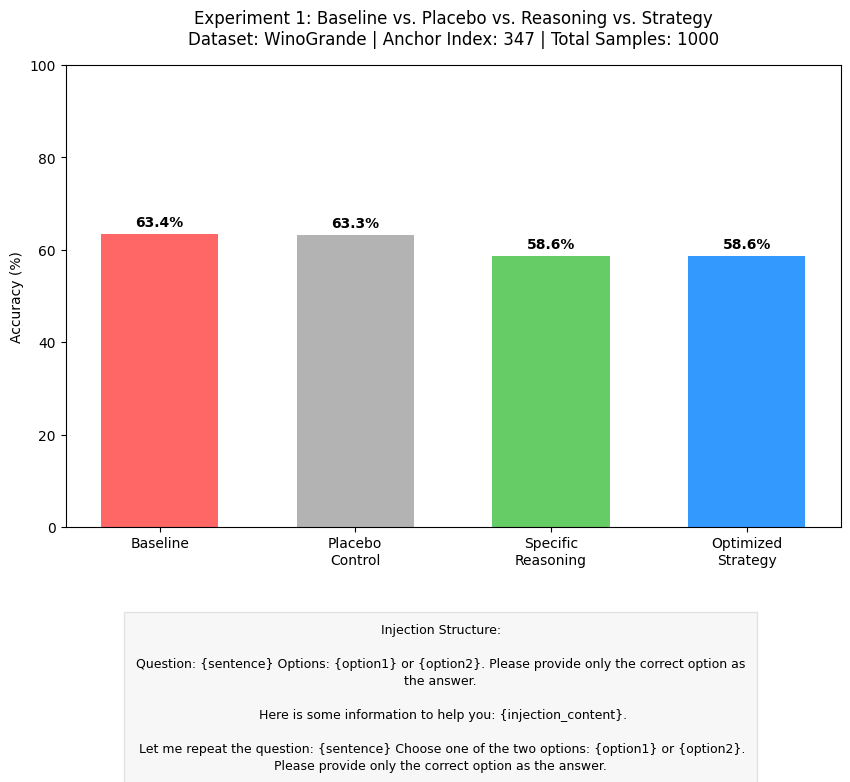

In [ ]:
import json
import matplotlib.pyplot as plt
import textwrap

# 1. Safely split the log into metadata and results
# (Assuming your JSON is loaded into the variable 'experiment_log')
metadata = experiment_log.get("metadata", {})
results = experiment_log.get("results", {})

total_samples = len(results)
baseline_correct = 0
injected_correct = 0
control_correct = 0
strategy_correct = 0 

for sample_id, data in results.items():
    # Convert to lowercase and strip whitespace for fair comparison
    solution = str(data.get("solution", "")).strip().lower()
    
    # Matching your exact JSON keys
    baseline = str(data.get("llm_baseline", "")).strip().lower()
    injected = str(data.get("llm_preprocessedReasoning", "")).strip().lower()
    strategy = str(data.get("llm_preprocessedOptimizedReasoning", "")).strip().lower()
    control  = str(data.get("llm_controlPlacebo", "")).strip().lower()
    
    # Check: Is the correct word contained in the model's answer?
    if solution in baseline:
        baseline_correct += 1
    if solution in injected:
        injected_correct += 1
    if solution in control:
        control_correct += 1
    if solution in strategy:
        strategy_correct += 1

# Calculate percentage accuracy
baseline_accuracy = (baseline_correct / total_samples) * 100 if total_samples > 0 else 0
injected_accuracy = (injected_correct / total_samples) * 100 if total_samples > 0 else 0
control_accuracy = (control_correct / total_samples) * 100 if total_samples > 0 else 0
strategy_accuracy = (strategy_correct / total_samples) * 100 if total_samples > 0 else 0

# 📊 The Big Reveal (Console Output)
print("📊 WinoGrande Experiment Results (4-Way Comparison):")
print("=" * 60)
print(f"Total Samples analyzed: {total_samples}")
print("-" * 60)
print(f"🔴 Baseline Accuracy:  {baseline_accuracy:.1f}% ({baseline_correct}/{total_samples})")
print(f"⚪ Placebo Control:    {control_accuracy:.1f}% ({control_correct}/{total_samples})")
print(f"🟢 Specific Reasoning: {injected_accuracy:.1f}% ({injected_correct}/{total_samples})")
print(f"🔵 Optimized Strategy: {strategy_accuracy:.1f}% ({strategy_correct}/{total_samples})")
print("=" * 60)

# Hypothesis Conclusion Generator
if strategy_accuracy > injected_accuracy and strategy_accuracy > baseline_accuracy:
    print("\n🎉 Massive Success: The Generalized Strategy outperformed both the Baseline and the Specific Reasoning! Meta-reasoning works.")
elif injected_accuracy > strategy_accuracy and injected_accuracy > baseline_accuracy:
    print("\n⚖️ Partial Success: Specific Reasoning helped, but the model struggled to apply the Generalized Strategy across the board.")
elif strategy_accuracy == baseline_accuracy and injected_accuracy == baseline_accuracy:
    print("\n⚠️ No Effect: Neither reasoning injection nor strategy injection significantly shifted the baseline performance.")
else:
    print("\n📉 Mixed Results: Check the chart. The injections may have introduced noise rather than helpful logic.")

# 📈 Generate and Save the Plot
labels = ['Baseline', 'Placebo\nControl', 'Specific\nReasoning', 'Optimized\nStrategy']
accuracies = [baseline_accuracy, control_accuracy, injected_accuracy, strategy_accuracy]
colors = ['#ff6666', '#b3b3b3', '#66cc66', '#3399ff'] # Red, Grey, Green, Blue

plt.figure(figsize=(10, 6)) 
bars = plt.bar(labels, accuracies, color=colors, width=0.6)

# 💡 Extract Metadata for the Plot
dataset_name = metadata.get("dataset", "Unknown")
anchor_index = metadata.get("anchor_sample_index", "Unknown")
# Grabbing the sample size directly from your metadata
reported_sample_size = metadata.get("sample_size", total_samples)

plt.ylabel('Accuracy (%)')

# Add a multi-line title containing the experiment parameters
plt.title(f'Experiment 1: Baseline vs. Placebo vs. Reasoning vs. Strategy\n'
          f'Dataset: {dataset_name} | Anchor Index: {anchor_index} | Total Samples: {reported_sample_size}', 
          fontsize=12, pad=15)

plt.ylim(0, 100) # Keep Y-axis fixed from 0 to 100 for proper scientific scale

# Add text annotations directly on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# 💡 Display the full Structure of the Injection Prompt over multiple lines
prompt_structure = metadata.get("injected_prompt_structure", "Structure not found.")

# Wrap the text paragraph by paragraph to preserve existing intentional newlines
wrapped_lines = []
for line in prompt_structure.split('\n'):
    wrapped_lines.append(textwrap.fill(line, width=95) if line else "")
prompt_structure_display = '\n'.join(wrapped_lines)

# Place the text box. va="top" ensures the box expands downwards dynamically
plt.figtext(0.5, -0.05, f"Injection Structure:\n\n{prompt_structure_display}", 
            ha="center", va="top", fontsize=9, linespacing=1.4,
            bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":8, "edgecolor":"#cccccc"})

# Save the plot
plot_filename = "qwen_experiment_plot_4way_final.png"
plt.savefig(plot_filename, bbox_inches='tight', dpi=300) 
print(f"\n📸 Plot successfully saved as: {plot_filename}")

# Display the plot directly in the Jupyter Notebook cell
plt.show()